# Speech Command Classifier — Local Jupyter Version
Run cells top to bottom. Dataset (~2.3 GB) auto-downloads on first run and is cached forever after.

In [36]:
# ── CELL 1: Imports ────────────────────────────────────────────────────────────
import os
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import DataLoader, random_split
from transformers import Wav2Vec2Model
from torchaudio.datasets import SPEECHCOMMANDS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

print('All imports OK')

All imports OK


In [37]:
# ── CELL 2: Paths (all files saved next to this notebook) ─────────────────────
base_path   = os.getcwd()
speech_path = os.path.join(base_path, 'speech_output')
os.makedirs(speech_path, exist_ok=True)

speech_model_path = os.path.join(speech_path, 'speech_model_10cmd_512.pth')
metrics_path      = os.path.join(speech_path, 'speech_metrics.pth')

print('Paths ready:', speech_path)

Paths ready: /home/btech02_06/Dl_Model_Training/speech_output


In [38]:
# ── CELL 3: GPU Check ──────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('Is CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA device name:', torch.cuda.get_device_name(0))
    print('PyTorch CUDA version:', torch.version.cuda)

Using device: cuda
Is CUDA available: True
CUDA device name: NVIDIA RTX 4000 Ada Generation
PyTorch CUDA version: 12.1


In [39]:
# ── CELL 4: Download / Load Dataset ───────────────────────────────────────────
root_path = os.path.join(base_path, 'data')
os.makedirs(root_path, exist_ok=True)

# Force v0.02 explicitly — v0.01 is missing stop/right/up/on/off
dataset = SPEECHCOMMANDS(root=root_path, url='speech_commands_v0.02', download=True)

commands = ['yes', 'no', 'stop', 'go', 'left', 'right', 'up', 'down', 'on', 'off']
commands_set = set(commands)

filtered_data = [item for item in dataset if item[2].lower() in commands_set]

print('Total samples after filtering:', len(filtered_data))

from collections import Counter
found = Counter(item[2].lower() for item in filtered_data)
print('\nSamples per command:')
for cmd in commands:
    print(f'  {cmd:8s}: {found.get(cmd, 0)}')

missing = [c for c in commands if found.get(c, 0) == 0]
if missing:
    print(f'\nERROR — still missing: {missing} — dataset download may have failed')
else:
    print('\nAll 10 commands present — good to proceed')

Total samples after filtering: 38546

Samples per command:
  yes     : 4044
  no      : 3941
  stop    : 3872
  go      : 3880
  left    : 3801
  right   : 3778
  up      : 3723
  down    : 3917
  on      : 3845
  off     : 3745

All 10 commands present — good to proceed


In [40]:
# ── CELL 5: Label Map & Speech-to-System Mapping ──────────────────────────────
speech_to_system = {
    'yes':   'yes',
    'no':    'no',
    'stop':  'stop',
    'go':    'help',
    'up':    'attention',
    'down':  'calm',
    'left':  'suspicious',
    'right': 'suspicious',
    'on':    'action',
    'off':   'cancel'
}

label_map = {cmd: i for i, cmd in enumerate(commands)}

def encode_label(label):
    return label_map[label]

In [41]:
# ── CELL 6: Preprocessing ─────────────────────────────────────────────────────
TARGET_LENGTH = 16000

def preprocess(waveform):
    if waveform.dim() > 1:
        waveform = waveform.mean(dim=0)
    if waveform.abs().max() > 0:
        waveform = waveform / waveform.abs().max()
    if waveform.size(0) > TARGET_LENGTH:
        waveform = waveform[:TARGET_LENGTH]
    else:
        pad_size = TARGET_LENGTH - waveform.size(0)
        waveform = torch.nn.functional.pad(waveform, (0, pad_size))
    return waveform


def collate_fn(batch):
    waveforms = []
    batch_labels = []
    for waveform, sr, label, *_ in batch:       # ← must be indented inside the function
        waveform = preprocess(waveform)
        waveforms.append(waveform)
        batch_labels.append(encode_label(label.lower()))
    return torch.stack(waveforms), torch.tensor(batch_labels)  # ← don't forget the return!

In [42]:
# ── CELL 7: DataLoaders ───────────────────────────────────────────────────────
train_size = int(0.8 * len(filtered_data))
val_size   = int(0.1 * len(filtered_data))
test_size  = len(filtered_data) - train_size - val_size

train_data, val_data, test_data = random_split(filtered_data, [train_size, val_size, test_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_data,   batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_data,  batch_size=16, shuffle=False, collate_fn=collate_fn)

print(f'Train: {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}')

Train: 30836  Val: 3854  Test: 3856


In [43]:
# ── CELL 8: Class Weights ─────────────────────────────────────────────────────
# FIX: original code used counts[i] which returns 0 for missing classes
# causing ZeroDivisionError. Now uses counts.get(i, 1) as a safe fallback.

counts = Counter([encode_label(item[2]) for item in filtered_data])

# Show distribution so you can spot any missing class
print('Samples per class:')
for i, cmd in enumerate(commands):
    print(f'  [{i}] {cmd:10s}: {counts.get(i, 0)} samples')

missing = [commands[i] for i in range(len(commands)) if counts.get(i, 0) == 0]
if missing:
    print(f'\nWARNING: these commands have 0 samples and will use weight=1.0: {missing}')

# Safe division: fall back to count=1 for any class with 0 samples
weights = [1.0 / counts.get(i, 1) for i in range(len(commands))]
weights = torch.tensor(weights, dtype=torch.float).to(device)
print('\nClass weights computed OK')

Samples per class:
  [0] yes       : 4044 samples
  [1] no        : 3941 samples
  [2] stop      : 3872 samples
  [3] go        : 3880 samples
  [4] left      : 3801 samples
  [5] right     : 3778 samples
  [6] up        : 3723 samples
  [7] down      : 3917 samples
  [8] on        : 3845 samples
  [9] off       : 3745 samples

Class weights computed OK


In [44]:
# ── CELL 9: Model Definition ──────────────────────────────────────────────────
class SpeechModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained(
            'facebook/wav2vec2-base',
            use_safetensors=True
        )

        # Freeze feature extractor
        for param in self.wav2vec.feature_extractor.parameters():
            param.requires_grad = False

        self.embedding = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        outputs   = self.wav2vec(x)
        features  = outputs.last_hidden_state.mean(dim=1)
        embedding = self.embedding(features)
        logits    = self.classifier(embedding)
        return embedding, logits

In [45]:
# ── CELL 10: Init Model / Load Checkpoint if Exists ───────────────────────────
model     = SpeechModel(len(commands)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss(weight=weights)

if os.path.exists(speech_model_path):
    print('Loading saved model...')
    # FIX: weights_only=False required because checkpoint stores a Python list (commands)
    checkpoint = torch.load(speech_model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print('Model loaded. Skip to evaluation cells if you do not want to retrain.')
else:
    print('No saved model found — will train from scratch.')

Loading weights: 100%|██████████████████████| 211/211 [00:00<00:00, 3291.73it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


No saved model found — will train from scratch.


In [46]:
# ── CELL 11: Training Loop ────────────────────────────────────────────────────
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0
patience     = 7
patience_counter = 0

EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()
    train_loss, train_correct, total_train = 0, 0, 0

    for batch_waveforms, batch_labels in train_loader:
        batch_waveforms = batch_waveforms.to(device)
        batch_labels    = batch_labels.to(device)

        optimizer.zero_grad()
        _, logits = model(batch_waveforms)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = torch.argmax(logits, dim=1)
        train_correct += (preds == batch_labels).sum().item()
        total_train   += batch_labels.size(0)

    train_loss /= len(train_loader)
    train_acc   = train_correct / total_train

    # Validation
    model.eval()
    val_loss, val_correct, total_val = 0, 0, 0

    with torch.no_grad():
        for batch_waveforms, batch_labels in val_loader:
            batch_waveforms = batch_waveforms.to(device)
            batch_labels    = batch_labels.to(device)
            _, logits = model(batch_waveforms)
            loss = criterion(logits, batch_labels)
            val_loss    += loss.item()
            preds        = torch.argmax(logits, dim=1)
            val_correct += (preds == batch_labels).sum().item()
            total_val   += batch_labels.size(0)

    val_loss /= len(val_loader)
    val_acc   = val_correct / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({'model_state_dict': model.state_dict(), 'commands': commands},
                   speech_model_path)
        print('  Saved best model')
    else:
        patience_counter += 1
        print(f'  Early stopping counter: {patience_counter}/{patience}')
        if patience_counter >= patience:
            print('Early stopping triggered')
            break


Epoch 1/30
  Train Loss: 0.5906 | Train Acc: 0.8659
  Val   Loss: 0.1245 | Val   Acc: 0.9709
  Saved best model

Epoch 2/30
  Train Loss: 0.2388 | Train Acc: 0.9286
  Val   Loss: 0.0945 | Val   Acc: 0.9774
  Saved best model

Epoch 3/30
  Train Loss: 0.2034 | Train Acc: 0.9348
  Val   Loss: 0.0858 | Val   Acc: 0.9741
  Early stopping counter: 1/7

Epoch 4/30
  Train Loss: 0.1870 | Train Acc: 0.9409
  Val   Loss: 0.0669 | Val   Acc: 0.9790
  Saved best model

Epoch 5/30
  Train Loss: 0.1734 | Train Acc: 0.9424
  Val   Loss: 0.0655 | Val   Acc: 0.9798
  Saved best model

Epoch 6/30
  Train Loss: 0.1691 | Train Acc: 0.9439
  Val   Loss: 0.0665 | Val   Acc: 0.9782
  Early stopping counter: 1/7

Epoch 7/30
  Train Loss: 0.1627 | Train Acc: 0.9462
  Val   Loss: 0.0603 | Val   Acc: 0.9818
  Saved best model

Epoch 8/30
  Train Loss: 0.1465 | Train Acc: 0.9504
  Val   Loss: 0.0623 | Val   Acc: 0.9811
  Early stopping counter: 1/7

Epoch 9/30
  Train Loss: 0.1453 | Train Acc: 0.9515
  Val   Lo

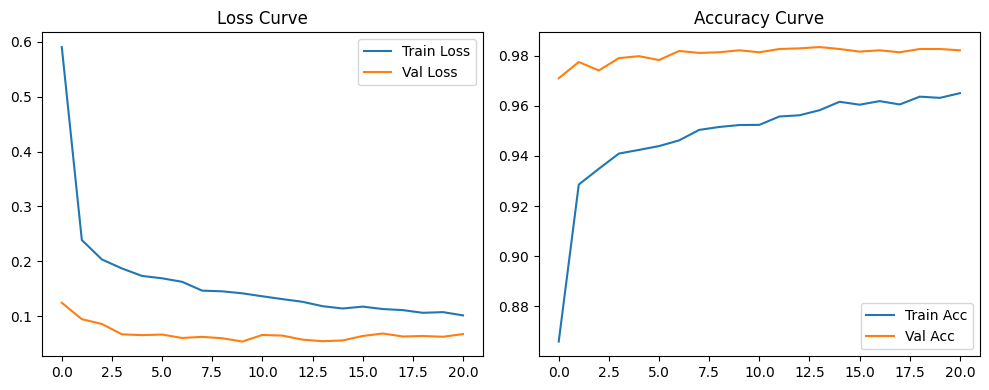

In [47]:
# ── CELL 12: Loss & Accuracy Curves ──────────────────────────────────────────
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs,   label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')

plt.tight_layout()
plt.show()

In [48]:
# ── CELL 13: Test Evaluation ──────────────────────────────────────────────────
# Load the best saved model before evaluating
checkpoint = torch.load(speech_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels = [], []
test_loss = 0

with torch.no_grad():
    for batch_waveforms, batch_labels in test_loader:
        batch_waveforms = batch_waveforms.to(device)
        batch_labels    = batch_labels.to(device)
        _, logits = model(batch_waveforms)
        loss = criterion(logits, batch_labels)
        test_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

test_loss /= len(test_loader)
print('Test Loss:', round(test_loss, 4))

Test Loss: 0.0666


In [49]:
# ── CELL 14: Classification Report ───────────────────────────────────────────
# FIX: pass labels= explicitly so sklearn reports all 10 classes even if
#      some have zero predictions in the test split.
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    labels=list(range(len(commands))),   # force all 10 classes
    target_names=commands,
    zero_division=0                       # show 0 instead of warning for empty classes
))

              precision    recall  f1-score   support

         yes       0.99      1.00      0.99       410
          no       0.98      0.99      0.99       398
        stop       0.99      0.99      0.99       393
          go       0.96      0.98      0.97       381
        left       0.99      0.98      0.98       375
       right       0.99      0.99      0.99       390
          up       0.97      0.97      0.97       369
        down       0.99      0.97      0.98       379
          on       0.98      0.95      0.97       385
         off       0.95      0.98      0.97       376

    accuracy                           0.98      3856
   macro avg       0.98      0.98      0.98      3856
weighted avg       0.98      0.98      0.98      3856



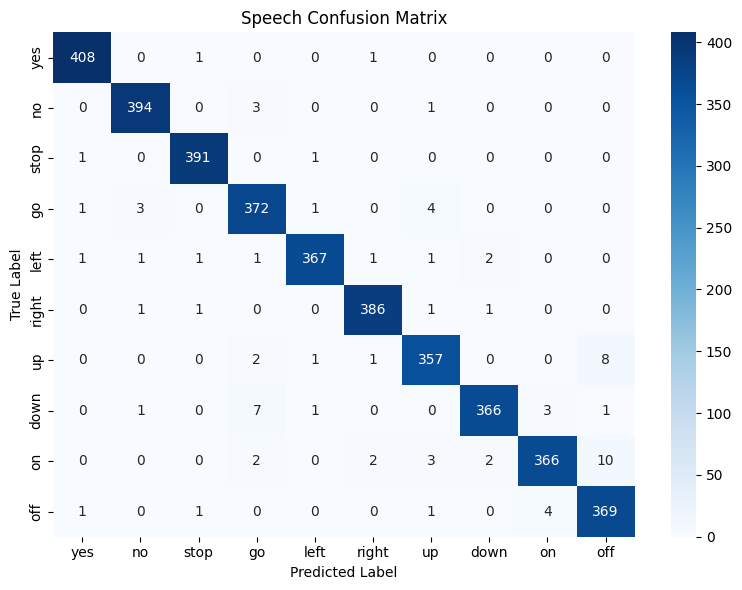

In [50]:
# ── CELL 15: Confusion Matrix ─────────────────────────────────────────────────
# FIX: pass labels= explicitly so matrix is always 10×10
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=list(range(len(commands)))    # force all 10 classes
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=commands, yticklabels=commands)
plt.title('Speech Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [51]:
# ── CELL 16: Extract & Save Embeddings ───────────────────────────────────────
model.eval()

speech_embeddings, speech_emb_labels = [], []

with torch.no_grad():
    for batch_waveforms, batch_labels in test_loader:
        batch_waveforms = batch_waveforms.to(device)
        embeddings, _   = model(batch_waveforms)
        speech_embeddings.append(embeddings.cpu())
        speech_emb_labels.append(batch_labels)

speech_embeddings  = torch.cat(speech_embeddings)
speech_emb_labels  = torch.cat(speech_emb_labels)

save_path = os.path.join(speech_path, 'speech_embeddings.pt')
torch.save({'embeddings': speech_embeddings, 'labels': speech_emb_labels}, save_path)

print('Speech embeddings saved to', save_path)
print('Embedding shape:', speech_embeddings.shape)

Speech embeddings saved to /home/btech02_06/Dl_Model_Training/speech_output/speech_embeddings.pt
Embedding shape: torch.Size([3856, 512])


In [52]:
# ── CELL 17: Predict on a Local Audio File ────────────────────────────────────
# Place a .wav file next to this notebook, then set the filename below.

audio_file = 'your_audio_file.wav'   # <-- change this to your actual file name

if os.path.exists(audio_file):
    waveform, sr = torchaudio.load(audio_file)
    waveform     = preprocess(waveform).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        embedding, logits = model(waveform)

    pred = commands[torch.argmax(logits[0]).item()]
    print('Predicted command:', pred)
    print('System action    :', speech_to_system[pred])
    print('Embedding shape  :', embedding.shape)
else:
    print(f'File not found: {audio_file}')
    print('Place a .wav file next to this notebook and update the filename above.')

File not found: your_audio_file.wav
Place a .wav file next to this notebook and update the filename above.
